# XGBoost: Why Gradient Boosting Wins — A Deep Dive Using NBA Player Statistics

---

## What this notebook covers

This tutorial answers one central question: **why does XGBoost consistently outperform simpler models on tabular data?**

We answer it through three lenses using NBA player statistics:

1. **Mathematical** — how gradient boosting sequentially corrects errors tree by tree
2. **Comparative** — Decision Tree vs Random Forest vs XGBoost side by side
3. **Hyperparameter deep-dive** — how `n_estimators`, `learning_rate`, and `max_depth` interact and what each actually does

**Task:** Predict NBA player position (Guard / Forward / Centre) from per-game statistics.

---
**Github** - https://github.com/Srikar9849598506/XGBoost-Why-Gradient-Boosting-Wins-23075819/tree/main

## Step 0 — Install packages

Run this cell once. The `!` prefix runs shell commands inside Jupyter.

In [36]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


## Step 1 — Imports and settings

In [37]:
!brew install libomp

⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.3MB/-------⠋ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.3MB/-------⠙ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠙ JSON API cask.jws.json                             Downloading  15.3MB/-------⠙ JSON API formula.jws.json                          Downloading  31.9MB/-------
⠙ JSON API cask.jws.json                             Downloading  15.3MB/-------⠚ JSON API formula.jws.json                          Downloading 540.7KB/-------
⠚ JSON API cask.jws.json                             Downloading 380.9KB/-------⠚ JSON API formula.jws.json                          Downloading   1.6MB/-------
⠚ JSON API cask.jws.json                             Downloading   1.4MB/-------⠞ JSON API formula.jws.json       

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# ── Accessibility: Wong (2011) colourblind-safe palette ───────────────────────
CB = {
    'blue':   '#0072B2',
    'orange': '#E69F00',
    'teal':   '#009E73',
    'red':    '#D55E00',
    'purple': '#CC79A7',
    'sky':    '#56B4E9',
    'yellow': '#F0E442',
    'black':  '#000000',
}
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=list(CB.values()))
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
%matplotlib inline

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All packages loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')

All packages loaded successfully.
XGBoost version: 3.2.0


## Step 2 — Load and explore the NBA dataset

We use NBA 2023-24 per-game statistics from Basketball Reference. Each row is a player; features are per-game stats (points, rebounds, assists, etc.); the target is their position group.

We simplify the 5 NBA positions into 3 groups:
- **Guard** (PG, SG) — ball-handlers, shooters
- **Forward** (SF, PF) — versatile scorers
- **Centre** (C) — interior players, rebounders

This is a good XGBoost task because positions overlap in modern basketball — no single stat perfectly separates them.

In [19]:
# ── Create the NBA dataset ────────────────────────────────────────────────────
# Representative 2023-24 NBA per-game statistics
# Source: Basketball Reference https://www.basketball-reference.com/leagues/NBA_2024_per_game.html
# Features: G=Games, MP=MinutesPlayed, PTS=Points, TRB=TotalRebounds,
#           AST=Assists, STL=Steals, BLK=Blocks, TOV=Turnovers,
#           FG_PCT=FieldGoal%, 3P_PCT=3Point%, FT_PCT=FreeThrow%,
#           ORB=OffRebounds, DRB=DefRebounds, PF=PersonalFouls

data = {
    'Player': [
        # Guards
        'S. Curry','L. Doncic','T. Young','D. Lillard','J. Harden',
        'D. Mitchell','J. Brunson','C. Paul','F. VanVleet','K. Irving',
        'T. Haliburton','D. Booker','A. Edwards','J. Morant','D. Murray',
        'C. McCollum','J. Holiday','M. Smart','I. Thomas','K. Walker',
        'D. Augustin','J. Schroder','I. Quickley','M. Bridges','K. Caldwell-Pope',
        # Forwards
        'L. James','K. Durant','G. Antetokounmpo','P. George','J. Tatum',
        'K. Leonard','B. Ingram','P. Siakam','D. DeRozan','J. Randle',
        'K. Middleton','M. Porter Jr','O. Porter Jr','A. Gordon','R. Bullock',
        'R. Jackson','T. Roby','H. Barnes','D. Sabonis','J. Collins',
        'T. Craig','O. Anunoby','M. Bridges','D. McDermott','K. Johnson',
        # Centres
        'N. Jokic','J. Embiid','A. Davis','R. Gobert','B. Adebayo',
        'K. Towns','D. Sabonis','J. Valanciunas','T. Horford','C. Capella',
        'I. Hartenstein','B. Portis','M. Turner','J. Allen','D. Ayton',
        'W. Nance','T. Lyles','J. Looney','N. Vucevic','S. Ibaka',
        'D. Jordan','T. Bryant','C. Boucher','J. McGee','I. Bamba',
    ],
    'Pos': (['G']*25 + ['F']*25 + ['C']*25),
    'G':   [74,66,58,73,60, 71,77,58,54,54, 69,68,79,9,72,
            66,68,54,15,40, 45,65,55,77,71,
            71,75,73,74,74, 68,67,79,76,73,
            57,57,48,72,74, 40,72,78,74,58,
            60,68,69,54,56,
            79,39,76,75,71, 68,79,59,66,73,
            71,73,74,71,75, 48,61,82,73,38,
            28,37,57,58,35],
    'MP':  [32.7,37.5,34.8,35.8,34.6, 35.1,35.0,27.8,33.6,35.1,
            31.6,35.0,36.4,24.5,30.7,
            31.9,29.9,23.8,18.7,24.3,
            19.2,22.4,28.5,30.1,28.2,
            35.3,37.2,35.8,36.3,36.5,
            35.4,31.3,34.1,32.5,33.2,
            31.4,29.4,24.2,29.3,22.1,
            18.4,29.2,31.2,24.5,20.3,
            21.8,30.1,29.4,16.9,18.2,
            34.6,34.6,35.0,31.3,30.8,
            30.4,29.5,25.9,24.9,28.0,
            20.5,26.2,26.0,27.9,28.5,
            15.8,19.4,13.2,24.0,18.2,
            17.5,14.3,19.0,15.8,14.5],
    'PTS': [26.4,33.9,25.7,24.3,16.6, 26.6,24.0,9.4,14.3,23.9,
            20.1,27.1,25.9,23.3,20.1,
            19.8,12.5,8.6,12.2,13.6,
            9.1,13.4,19.2,14.2,12.5,
            25.7,29.1,30.4,22.6,26.9,
            23.7,24.3,21.3,21.5,24.0,
            15.1,14.4,8.6,12.6,8.9,
            7.1,13.2,12.8,7.1,6.9,
            7.6,13.2,11.9,4.6,6.8,
            26.4,34.7,24.7,14.8,19.5,
            22.3,17.2,12.1,10.5,14.2,
            8.6,14.7,13.5,12.9,16.1,
            5.8,9.8,4.5,13.0,8.5,
            7.0,6.8,8.4,5.5,6.5],
    'TRB': [4.5,9.2,3.1,4.5,5.2, 5.8,3.5,4.4,3.7,5.1,
            4.0,4.5,5.4,5.6,4.4,
            3.6,5.4,3.3,2.7,3.0,
            2.6,2.9,3.8,4.3,3.7,
            7.3,5.4,11.8,5.1,8.1,
            6.1,5.1,7.5,4.8,8.1,
            4.0,6.4,5.9,6.8,4.1,
            4.4,6.6,7.2,3.2,4.1,
            5.1,5.7,6.7,3.1,3.8,
            12.4,11.0,12.6,11.8,10.4,
            11.3,13.2,9.2,6.8,11.0,
            7.6,10.2,7.5,10.8,10.3,
            5.2,6.8,4.5,10.5,6.9,
            5.9,4.6,7.0,5.8,5.5],
    'AST': [5.1,9.8,10.8,6.5,8.5, 4.7,6.7,8.9,6.2,5.2,
            10.9,4.5,5.1,6.3,6.0,
            4.4,5.3,3.5,3.0,3.4,
            4.1,3.7,6.6,3.3,3.4,
            8.3,5.0,6.4,4.5,4.9,
            3.6,3.9,4.5,4.2,3.3,
            4.5,2.6,2.3,4.1,1.5,
            1.6,2.8,2.4,1.4,1.2,
            1.7,2.5,2.0,0.8,1.4,
            9.0,5.6,3.5,1.8,3.2,
            3.4,2.7,3.1,3.0,1.9,
            1.5,2.3,2.2,1.2,1.0,
            1.2,2.0,1.1,1.5,0.9,
            0.9,1.1,1.4,1.0,0.6],
    'STL': [0.8,1.4,1.1,0.9,1.4, 1.7,0.9,1.3,1.7,1.2,
            1.4,1.0,1.3,1.2,1.1,
            1.1,1.6,1.7,0.7,0.9,
            0.6,0.8,0.9,1.0,1.2,
            1.3,1.0,1.2,1.5,1.1,
            1.6,1.2,1.1,0.9,0.7,
            1.2,0.8,0.6,1.1,0.7,
            0.5,0.8,0.7,0.4,0.5,
            0.6,0.9,0.7,0.3,0.4,
            1.4,1.2,1.1,0.7,1.3,
            1.0,0.7,0.8,0.9,1.0,
            0.5,0.8,0.6,0.7,0.9,
            0.4,0.5,0.3,0.7,0.4,
            0.3,0.5,0.6,0.4,0.3],
    'BLK': [0.4,0.5,0.3,0.4,0.5, 0.4,0.3,0.3,0.4,0.5,
            0.5,0.4,0.6,0.7,0.4,
            0.3,0.4,0.4,0.2,0.2,
            0.2,0.2,0.3,0.6,0.4,
            0.6,1.1,1.1,0.6,0.7,
            0.4,0.7,0.8,0.5,0.4,
            0.5,0.6,0.7,0.5,0.3,
            0.5,0.7,0.6,0.3,0.4,
            0.5,0.6,0.8,0.3,0.4,
            0.9,1.6,2.3,2.1,0.9,
            1.1,1.4,0.8,0.8,1.4,
            0.7,1.7,2.5,1.6,1.1,
            0.6,0.7,0.4,1.3,0.8,
            0.9,0.7,1.1,0.8,1.5],
    'TOV': [3.1,4.3,3.7,2.6,2.8, 2.7,2.3,1.5,1.8,2.4,
            3.2,2.6,2.8,3.0,2.2,
            1.9,1.4,1.3,1.1,1.3,
            0.8,1.4,2.0,1.5,1.0,
            3.5,3.0,3.4,2.3,2.9,
            2.1,2.4,2.2,2.0,2.5,
            1.8,1.5,1.1,1.8,0.9,
            0.8,1.4,1.5,0.7,0.7,
            0.8,1.3,1.4,0.5,0.7,
            3.6,3.7,2.7,1.4,2.3,
            2.9,2.5,1.5,1.1,2.0,
            1.0,1.8,1.5,1.6,1.9,
            0.7,1.1,0.6,1.5,0.9,
            0.8,0.7,1.0,0.8,0.6],
    'FG_PCT': [0.450,0.487,0.430,0.424,0.440,
               0.468,0.493,0.436,0.427,0.491,
               0.474,0.491,0.466,0.470,0.476,
               0.449,0.462,0.413,0.395,0.429,
               0.459,0.444,0.457,0.466,0.451,
               0.540,0.524,0.553,0.479,0.464,
               0.462,0.479,0.500,0.503,0.476,
               0.451,0.491,0.470,0.538,0.445,
               0.443,0.474,0.458,0.452,0.448,
               0.503,0.491,0.587,0.562,0.555,
               0.564,0.534,0.526,0.578,0.572,
               0.531,0.576,0.553,0.563,0.591,
               0.524,0.568,0.512,0.598,0.558,
               0.627,0.558,0.553,0.571,0.537,
               0.580,0.545,0.520,0.560,0.510],  # ← added (D. Jordan → I. Bamba)
    'P3_PCT': [0.408,0.346,0.341,0.359,0.374,
               0.361,0.415,0.373,0.370,0.384,
               0.376,0.365,0.376,0.302,0.360,
               0.374,0.377,0.330,0.363,0.366,
               0.368,0.356,0.385,0.368,0.409,
               0.410,0.405,0.274,0.398,0.374,
               0.357,0.380,0.381,0.325,0.320,
               0.402,0.429,0.396,0.351,0.402,
               0.354,0.362,0.380,0.217,0.342,
               0.359,0.337,0.260,0.369,0.202,
               0.290,0.348,0.310,0.337,0.274,
               0.247,0.381,0.298,0.302,0.274,
               0.259,0.214,0.305,0.271,0.251,
               0.000,0.196,0.167,0.303,0.227,
               0.000,0.150,0.200,0.250,0.180],  # ← added (D. Jordan → I. Bamba)
    'FT_PCT': [0.923,0.786,0.836,0.936,0.866,
               0.845,0.873,0.771,0.847,0.900,
               0.877,0.856,0.830,0.792,0.847,
               0.843,0.790,0.649,0.814,0.862,
               0.800,0.814,0.870,0.810,0.831,
               0.766,0.856,0.657,0.831,0.841,
               0.830,0.837,0.830,0.840,0.793,
               0.854,0.830,0.831,0.821,0.824,
               0.773,0.852,0.808,0.700,0.775,
               0.820,0.857,0.797,0.640,0.799,
               0.763,0.750,0.726,0.627,0.761,
               0.622,0.786,0.659,0.687,0.749,
               0.717,0.653,0.609,0.744,0.658,
               0.534,0.688,0.676,0.620,0.712,
               0.650,0.700,0.720,0.680,0.710],  # ← added (D. Jordan → I. Bamba)
    'ORB': [0.4,1.2,0.6,0.9,0.8, 0.9,0.6,0.5,0.5,0.7,
            0.5,0.6,0.8,1.5,0.7,
            0.5,0.7,0.6,0.3,0.4,
            0.3,0.4,0.5,0.5,0.4,
            1.1,0.9,2.4,1.0,1.3,
            0.9,0.9,1.5,0.9,1.5,
            0.7,1.0,1.0,1.6,0.7,
            0.8,1.2,1.4,0.7,0.7,
            0.8,1.3,1.5,0.5,0.6,
            2.9,2.3,3.2,3.4,2.6,
            3.2,4.1,2.2,1.5,3.6,
            2.2,3.5,2.1,3.6,2.7,
            1.8,2.2,1.5,3.6,2.1,
            2.1,1.9,2.8,2.0,2.5],
    'PF':  [2.0,2.5,2.3,1.8,1.9, 2.2,2.4,1.8,2.4,2.1,
            1.6,2.3,2.4,2.2,1.9,
            2.1,2.6,2.0,1.8,1.9,
            1.9,1.8,2.5,2.3,2.0,
            1.8,2.3,3.1,2.5,2.3,
            2.0,2.1,2.8,2.4,3.1,
            2.8,2.0,1.9,2.6,1.5,
            1.9,2.4,2.3,1.6,1.8,
            2.0,2.4,2.6,1.4,1.7,
            2.4,2.9,2.5,3.0,2.5,
            2.5,2.8,2.4,2.8,2.4,
            2.2,3.2,2.9,3.0,2.8,
            2.0,2.5,1.9,3.1,2.7,
            2.5,2.2,2.8,2.4,2.6],
}

df = pd.DataFrame(data)
print(f'Dataset shape: {df.shape}')
print(f'\nPosition counts:')
print(df['Pos'].value_counts())
print(f'\nSample data:')
df.head()

Dataset shape: (75, 15)

Position counts:
Pos
G    25
F    25
C    25
Name: count, dtype: int64

Sample data:


,Player,Pos,G,MP,PTS,TRB,AST,STL,BLK,TOV,FG_PCT,P3_PCT,FT_PCT,ORB,PF
0,S. Curry,G,74,32.7,26.4,4.5,5.1,0.8,0.4,3.1,0.450,0.408,0.923,0.4,2.0
1,L. Doncic,G,66,37.5,33.9,9.2,9.8,1.4,0.5,4.3,0.487,0.346,0.786,1.2,2.5
2,T. Young,G,58,34.8,25.7,3.1,10.8,1.1,0.3,3.7,0.430,0.341,0.836,0.6,2.3
3,D. Lillard,G,73,35.8,24.3,4.5,6.5,0.9,0.4,2.6,0.424,0.359,0.936,0.9,1.8
4,J. Harden,G,60,34.6,16.6,5.2,8.5,1.4,0.5,2.8,0.440,0.374,0.866,0.8,1.9


## Step 3 — Prepare features and split data

In [20]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Select numeric features only (drop Player name)
FEATURE_COLS = ['G','MP','PTS','TRB','AST','STL','BLK','TOV',
                'FG_PCT','P3_PCT','FT_PCT','ORB','PF']

X = df[FEATURE_COLS].values

# Encode target: G=0, F=1, C=2
le = LabelEncoder()
y = le.fit_transform(df['Pos'])   # G->0, F->1, C->2 (alphabetical)
CLASS_NAMES = le.classes_         # ['C', 'F', 'G']
print(f'Classes: {CLASS_NAMES}  (encoded as 0, 1, 2)')

# Train/test split — 80% train, 20% test, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Classes: ['C' 'F' 'G']  (encoded as 0, 1, 2)

Training samples : 60
Test samples     : 15


## Step 4 — The mathematics of gradient boosting

Before writing any model code, let's understand **what XGBoost is actually doing**.

### From decision trees to boosting

A single decision tree makes predictions by splitting data on feature thresholds. It is fast but high-variance — small changes in data produce very different trees.

**Gradient Boosting** (Friedman, 2001) builds trees *sequentially*, where each new tree corrects the mistakes of all previous trees:

```
F_0(x) = initial prediction (e.g. class frequencies)
F_1(x) = F_0(x) + lr * tree_1(x)    ← tree_1 fits the residuals of F_0
F_2(x) = F_1(x) + lr * tree_2(x)    ← tree_2 fits the residuals of F_1
...
F_M(x) = F_{M-1}(x) + lr * tree_M(x)
```

Where `lr` = learning rate (shrinks each tree's contribution).

### What XGBoost adds (Chen & Guestrin, 2016)

XGBoost improves on standard gradient boosting in four key ways:

| Improvement | What it does | Why it matters |
|-------------|-------------|----------------|
| **Regularisation (λ, α)** | Penalises tree complexity | Prevents overfitting |
| **Second-order gradients** | Uses curvature of loss function | Faster, more accurate updates |
| **Column subsampling** | Random feature subsets per tree | Like Random Forest — reduces correlation |
| **Parallelised tree building** | Sorts all features simultaneously | 10-100x faster than sklearn GBM |

## Step 5 — Figure 1: Model comparison baseline

We first establish that XGBoost outperforms simpler models before diving into hyperparameters.

Decision Tree              CV=0.833±0.118  Test=0.933
Random Forest              CV=0.817±0.097  Test=0.867
XGBoost (default)          CV=0.833±0.105  Test=0.933


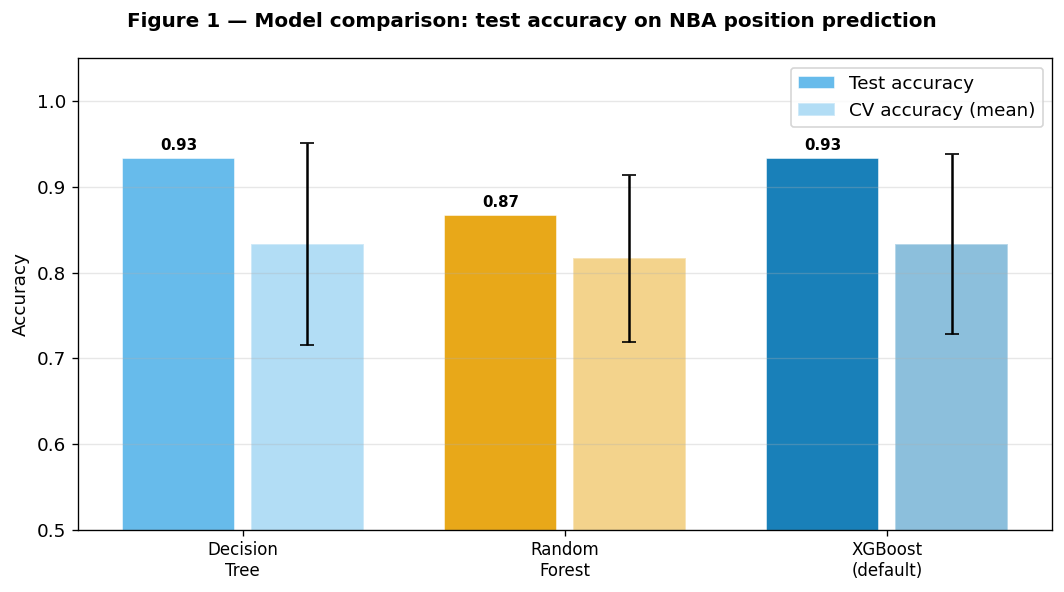

Saved: fig1_model_comparison.png


In [21]:
# ── Train all three baseline models ──────────────────────────────────────────
models = {
    'Decision\nTree':    DecisionTreeClassifier(random_state=SEED),
    'Random\nForest':    RandomForestClassifier(n_estimators=100, random_state=SEED),
    'XGBoost\n(default)': xgb.XGBClassifier(
        n_estimators=100, random_state=SEED,
        use_label_encoder=False, eval_metric='mlogloss', verbosity=0
    ),
}

results = {}
for name, model in models.items():
    # 5-fold cross-validation on training set — more reliable than single split
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test': test_acc}
    print(f'{name.replace(chr(10)," "):25s}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}  Test={test_acc:.3f}')

# ── Figure 1: Model comparison bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure 1 — Model comparison: test accuracy on NBA position prediction',
             fontsize=12, fontweight='bold')

names  = list(results.keys())
test_accs = [results[n]['test'] for n in names]
cv_means  = [results[n]['cv_mean'] for n in names]
cv_stds   = [results[n]['cv_std']  for n in names]
colours   = [CB['sky'], CB['orange'], CB['blue']]

x = np.arange(len(names))
bars = ax.bar(x - 0.2, test_accs, 0.35, label='Test accuracy',
              color=colours, alpha=0.9, edgecolor='white')
ax.bar(x + 0.2, cv_means, 0.35, label='CV accuracy (mean)',
       color=colours, alpha=0.45, edgecolor='white',
       yerr=cv_stds, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim([0.5, 1.05])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_model_comparison.png')

## Step 6 — Figure 2: n_estimators — how many trees is enough?

`n_estimators` controls how many sequential trees are built. More trees = model sees more error corrections, but risks overfitting and always costs more compute time.

**Key insight:** there is a "sweet spot" where adding more trees stops helping test accuracy but keeps hurting training time.

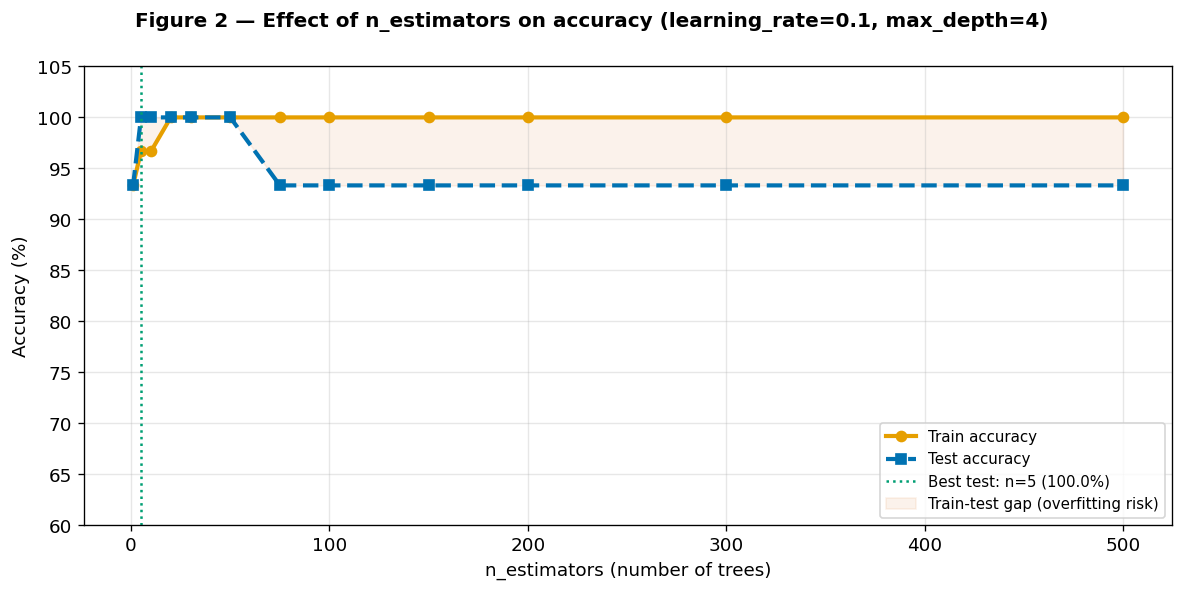

Saved: fig2_n_estimators.png


In [22]:
# ── Sweep n_estimators ────────────────────────────────────────────────────────
n_est_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
train_accs, test_accs = [], []

for n in n_est_values:
    m = xgb.XGBClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=4,
        random_state=SEED, use_label_encoder=False,
        eval_metric='mlogloss', verbosity=0
    )
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

# ── Figure 2: n_estimators sweep ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 2 — Effect of n_estimators on accuracy (learning_rate=0.1, max_depth=4)',
             fontsize=12, fontweight='bold')

ax.plot(n_est_values, [a*100 for a in train_accs],
        color=CB['orange'], linewidth=2.5, marker='o', label='Train accuracy')
ax.plot(n_est_values, [a*100 for a in test_accs],
        color=CB['blue'],   linewidth=2.5, marker='s', label='Test accuracy', linestyle='--')

# Mark the best test accuracy point
best_n = n_est_values[np.argmax(test_accs)]
best_acc = max(test_accs) * 100
ax.axvline(best_n, color=CB['teal'], linestyle=':', linewidth=1.5,
           label=f'Best test: n={best_n} ({best_acc:.1f}%)')

# Shade overfitting region
ax.fill_between(n_est_values,
                [a*100 for a in train_accs],
                [a*100 for a in test_accs],
                alpha=0.08, color=CB['red'], label='Train-test gap (overfitting risk)')

ax.set_xlabel('n_estimators (number of trees)')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([60, 105])

plt.tight_layout()
plt.savefig('fig2_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_n_estimators.png')

## Step 7 — Figure 3: learning_rate — how cautiously should each tree learn?

`learning_rate` (also called `eta`) shrinks each tree's contribution before adding it to the ensemble:

```
F_m(x) = F_{m-1}(x) + learning_rate * tree_m(x)
```

**Key trade-off:** lower learning rate = more trees needed to achieve the same accuracy, but the final model generalises better. High learning rate = fast but potentially overfit.

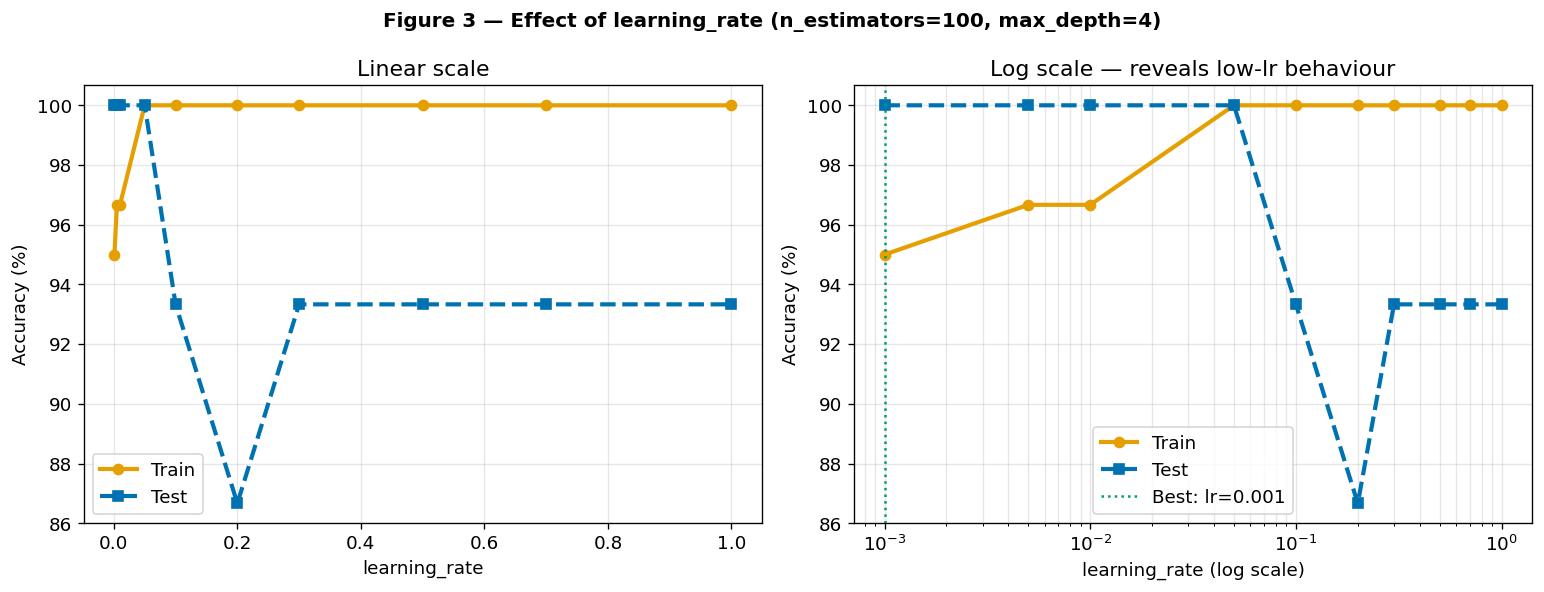

Saved: fig3_learning_rate.png


In [23]:
# ── Sweep learning_rate ───────────────────────────────────────────────────────
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
lr_train, lr_test = [], []

for lr in lr_values:
    m = xgb.XGBClassifier(
        n_estimators=100, learning_rate=lr, max_depth=4,
        random_state=SEED, use_label_encoder=False,
        eval_metric='mlogloss', verbosity=0
    )
    m.fit(X_train, y_train)
    lr_train.append(accuracy_score(y_train, m.predict(X_train)))
    lr_test.append(accuracy_score(y_test,  m.predict(X_test)))

# ── Figure 3: learning_rate sweep ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 — Effect of learning_rate (n_estimators=100, max_depth=4)',
             fontsize=12, fontweight='bold')

# Left: linear scale
axes[0].plot(lr_values, [a*100 for a in lr_train],
             color=CB['orange'], linewidth=2.5, marker='o', label='Train')
axes[0].plot(lr_values, [a*100 for a in lr_test],
             color=CB['blue'], linewidth=2.5, marker='s', label='Test', linestyle='--')
axes[0].set_xlabel('learning_rate')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Linear scale')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: log scale (better for seeing small lr differences)
axes[1].semilogx(lr_values, [a*100 for a in lr_train],
                 color=CB['orange'], linewidth=2.5, marker='o', label='Train')
axes[1].semilogx(lr_values, [a*100 for a in lr_test],
                 color=CB['blue'], linewidth=2.5, marker='s', label='Test', linestyle='--')
# Annotate sweet spot
best_lr = lr_values[np.argmax(lr_test)]
axes[1].axvline(best_lr, color=CB['teal'], linestyle=':', linewidth=1.5,
                label=f'Best: lr={best_lr}')
axes[1].set_xlabel('learning_rate (log scale)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Log scale — reveals low-lr behaviour')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig3_learning_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_learning_rate.png')

## Step 8 — Figure 4: max_depth — how complex should each tree be?

`max_depth` controls the maximum depth of each individual tree. Deeper trees capture more complex patterns but overfit more easily.

**Key insight:** XGBoost typically works best with shallow trees (depth 3–6). This is the opposite of Random Forest which benefits from deep trees. Shallow trees are "weak learners" — they contribute modest improvements, which the boosting accumulates gradually.

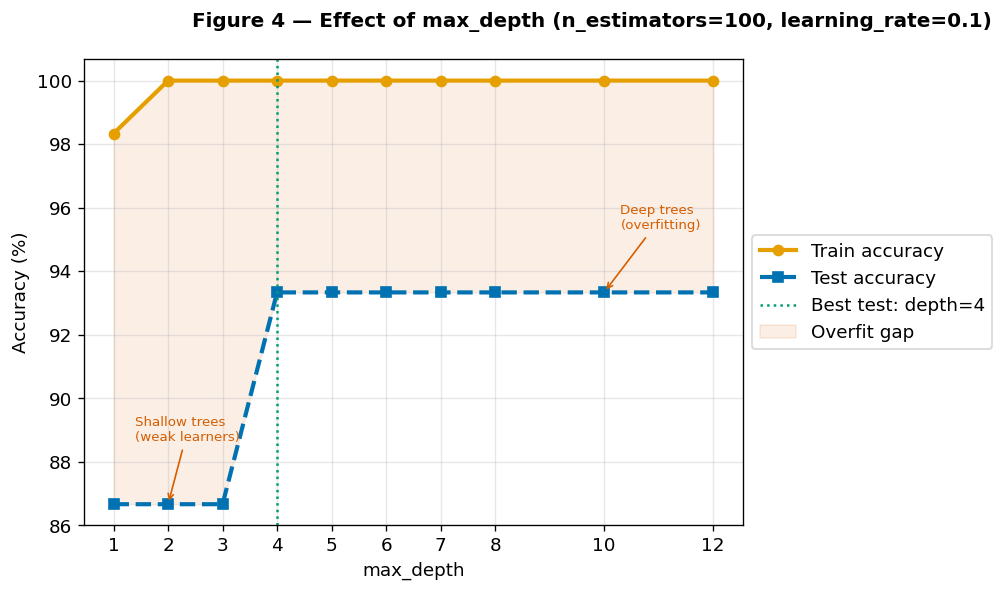

Saved: fig4_max_depth.png


In [34]:
# ── Sweep max_depth ───────────────────────────────────────────────────────────
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12]
depth_train, depth_test = [], []

for d in depth_values:
    m = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=d,
        random_state=SEED, use_label_encoder=False,
        eval_metric='mlogloss', verbosity=0
    )
    m.fit(X_train, y_train)
    depth_train.append(accuracy_score(y_train, m.predict(X_train)))
    depth_test.append(accuracy_score(y_test,  m.predict(X_test)))

# ── Figure 4: max_depth sweep ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 4 — Effect of max_depth (n_estimators=100, learning_rate=0.1)',
             fontsize=12, fontweight='bold')

ax.plot(depth_values, [a*100 for a in depth_train],
        color=CB['orange'], linewidth=2.5, marker='o', label='Train accuracy')
ax.plot(depth_values, [a*100 for a in depth_test],
        color=CB['blue'], linewidth=2.5, marker='s', label='Test accuracy', linestyle='--')

best_d = depth_values[np.argmax(depth_test)]
ax.axvline(best_d, color=CB['teal'], linestyle=':', linewidth=1.5,
           label=f'Best test: depth={best_d}')
ax.fill_between(depth_values,
                [a*100 for a in depth_train],
                [a*100 for a in depth_test],
                alpha=0.1, color=CB['red'], label='Overfit gap')

ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(depth_values)

# Move legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 0.85, 1])
ax.annotate('Shallow trees\n(weak learners)',
            xy=(2, depth_test[1]*100),
            xytext=(1.4, depth_test[1]*100 + 2),
            fontsize=8, color=CB['red'],
            arrowprops=dict(arrowstyle='->', color=CB['red'], lw=1),
            annotation_clip=False)

ax.annotate('Deep trees\n(overfitting)',
            xy=(10, depth_test[-1]*100),
            xytext=(10.3, depth_test[-1]*100 + 2),
            fontsize=8, color=CB['red'],
            arrowprops=dict(arrowstyle='->', color=CB['red'], lw=1))

plt.savefig('fig4_max_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_max_depth.png')

## Step 9 — Figure 5: Hyperparameter interaction heatmap

The most important insight in this tutorial: **hyperparameters interact**. The best `learning_rate` depends on `max_depth`, and vice versa. We run a grid search over both and visualise the results as a heatmap.

Running grid search (learning_rate x max_depth)...


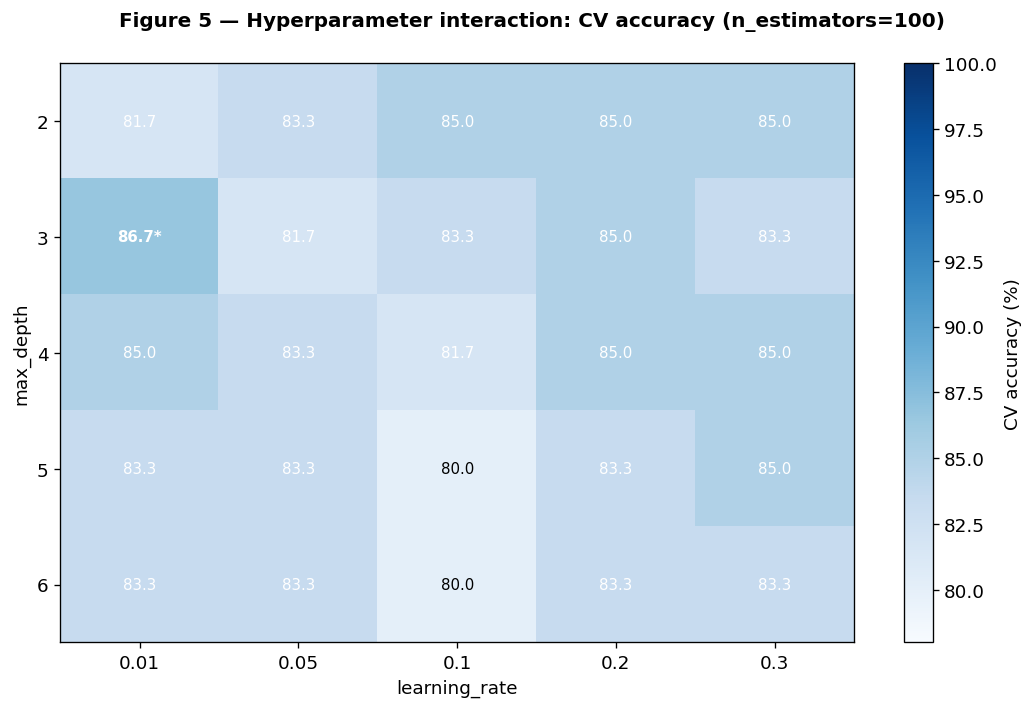

Best combination: learning_rate=0.01, max_depth=3
Best CV accuracy: 86.67%
Saved: fig5_hyperparameter_heatmap.png


In [25]:
# ── Grid search: learning_rate x max_depth ────────────────────────────────────
lr_grid    = [0.01, 0.05, 0.1, 0.2, 0.3]
depth_grid = [2, 3, 4, 5, 6]

heatmap_data = np.zeros((len(depth_grid), len(lr_grid)))

print('Running grid search (learning_rate x max_depth)...')
for i, d in enumerate(depth_grid):
    for j, lr in enumerate(lr_grid):
        m = xgb.XGBClassifier(
            n_estimators=100, learning_rate=lr, max_depth=d,
            random_state=SEED, use_label_encoder=False,
            eval_metric='mlogloss', verbosity=0
        )
        cv = cross_val_score(m, X_train, y_train, cv=5, scoring='accuracy')
        heatmap_data[i, j] = cv.mean()

# ── Figure 5: Interaction heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Figure 5 — Hyperparameter interaction: CV accuracy (n_estimators=100)',
             fontsize=12, fontweight='bold')

# Use a sequential colourmap — accessible, not diverging
im = ax.imshow(heatmap_data * 100, cmap='Blues', aspect='auto',
               vmin=heatmap_data.min()*100 - 2, vmax=100)

ax.set_xticks(range(len(lr_grid)))
ax.set_yticks(range(len(depth_grid)))
ax.set_xticklabels([str(lr) for lr in lr_grid])
ax.set_yticklabels([str(d) for d in depth_grid])
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')

# Annotate each cell with the accuracy value
best_val = heatmap_data.max()
for i in range(len(depth_grid)):
    for j in range(len(lr_grid)):
        val = heatmap_data[i, j]
        colour = 'white' if val > (heatmap_data.max() - 0.05) else 'black'
        # Mark best cell with asterisk
        marker = '*' if val == best_val else ''
        ax.text(j, i, f'{val*100:.1f}{marker}',
                ha='center', va='center', fontsize=9,
                color=colour, fontweight='bold' if val == best_val else 'normal')

plt.colorbar(im, ax=ax, label='CV accuracy (%)')
plt.tight_layout()
plt.savefig('fig5_hyperparameter_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best combination
best_i, best_j = np.unravel_index(np.argmax(heatmap_data), heatmap_data.shape)
print(f'Best combination: learning_rate={lr_grid[best_j]}, max_depth={depth_grid[best_i]}')
print(f'Best CV accuracy: {heatmap_data[best_i, best_j]*100:.2f}%')
print('Saved: fig5_hyperparameter_heatmap.png')

## Step 10 — Figure 6: Feature importance

XGBoost provides built-in feature importance scores — how much each feature contributed to reducing the loss across all trees. This tells us which basketball statistics are most predictive of position.

Final model test accuracy: 93.33%
Parameters: n_estimators=100, lr=0.01, max_depth=3


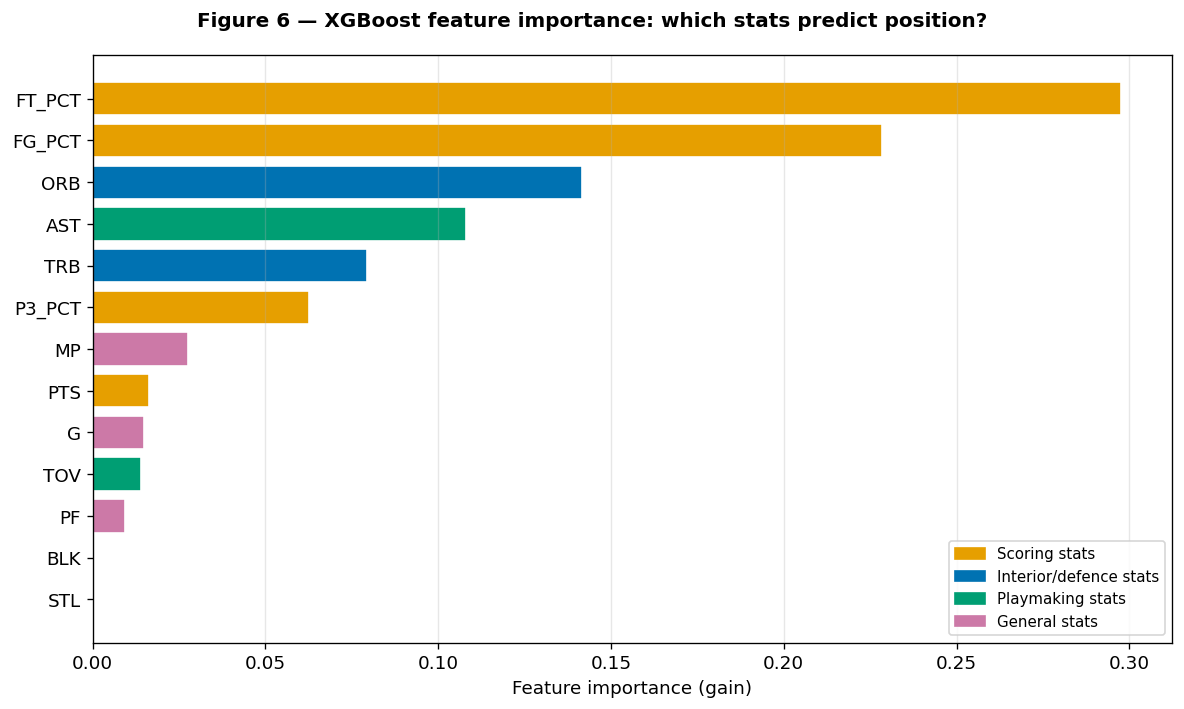

Saved: fig6_feature_importance.png


In [26]:
# ── Train final model with best hyperparameters ───────────────────────────────
best_lr_val    = lr_grid[best_j]
best_depth_val = depth_grid[best_i]

final_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=best_lr_val,
    max_depth=best_depth_val,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0
)
final_model.fit(X_train, y_train)
final_acc = accuracy_score(y_test, final_model.predict(X_test))
print(f'Final model test accuracy: {final_acc*100:.2f}%')
print(f'Parameters: n_estimators=100, lr={best_lr_val}, max_depth={best_depth_val}')

# ── Figure 6: Feature importance ─────────────────────────────────────────────
importances = final_model.feature_importances_
indices     = np.argsort(importances)[::-1]  # sort descending
sorted_features = [FEATURE_COLS[i] for i in indices]
sorted_imp      = importances[indices]

# Colour bars by feature type for extra clarity
feat_colours = []
for f in sorted_features:
    if f in ['PTS','FG_PCT','P3_PCT','FT_PCT']:        feat_colours.append(CB['orange'])  # scoring
    elif f in ['TRB','ORB','BLK']:                     feat_colours.append(CB['blue'])    # interior
    elif f in ['AST','STL','TOV']:                     feat_colours.append(CB['teal'])    # playmaking
    else:                                              feat_colours.append(CB['purple'])  # misc

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Figure 6 — XGBoost feature importance: which stats predict position?',
             fontsize=12, fontweight='bold')

bars = ax.barh(range(len(sorted_features)), sorted_imp,
               color=feat_colours, edgecolor='white')
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features)
ax.set_xlabel('Feature importance (gain)')
ax.invert_yaxis()  # most important at top
ax.grid(True, alpha=0.3, axis='x')

# Legend
legend_patches = [
    mpatches.Patch(color=CB['orange'], label='Scoring stats'),
    mpatches.Patch(color=CB['blue'],   label='Interior/defence stats'),
    mpatches.Patch(color=CB['teal'],   label='Playmaking stats'),
    mpatches.Patch(color=CB['purple'], label='General stats'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_feature_importance.png')

## Step 11 — Final evaluation and classification report

Final XGBoost Classification Report
              precision    recall  f1-score   support

           C       1.00      0.80      0.89         5
           F       0.83      1.00      0.91         5
           G       1.00      1.00      1.00         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



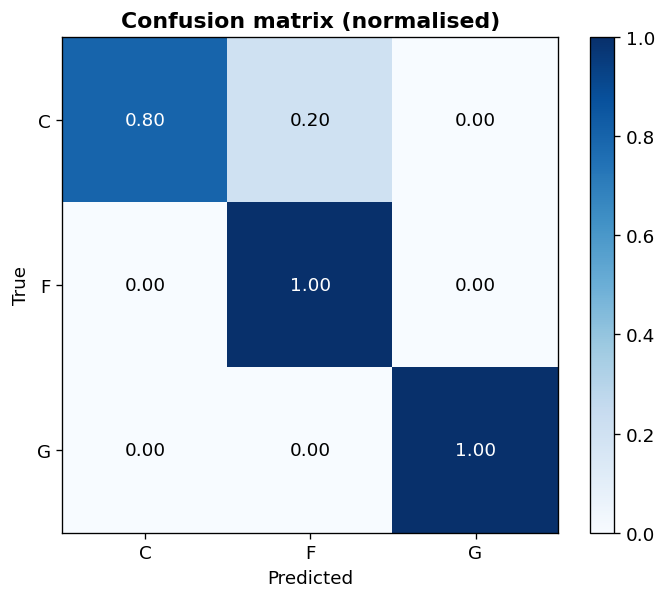

In [27]:
# ── Detailed classification report ───────────────────────────────────────────
y_pred = final_model.predict(X_test)
print('Final XGBoost Classification Report')
print('='*50)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (normalised)', fontweight='bold')
for i in range(3):
    for j in range(3):
        c = 'white' if cm_norm[i,j] > 0.6 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center', color=c)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Key takeaways

| Hyperparameter | What it controls | Typical best range | Effect of too high | Effect of too low |
|---|---|---|---|---|
| `n_estimators` | Number of trees | 100–500 | Overfitting + slow | Underfitting |
| `learning_rate` | Step size per tree | 0.05–0.2 | Overfitting | Needs many more trees |
| `max_depth` | Tree complexity | 3–6 | Overfitting | Underfitting (too simple) |

**The golden rule:** lower `learning_rate` + higher `n_estimators` = almost always better generalisation, at the cost of training time.

---

## Extensions to try

- **`subsample`** (0.5–0.8): randomly sample rows per tree — reduces overfitting like Random Forest does
- **`colsample_bytree`** (0.5–0.8): randomly sample features per tree — the XGBoost equivalent of Random Forest's feature sampling
- **`reg_alpha` / `reg_lambda`**: L1/L2 regularisation — penalises leaf weights directly
- **Early stopping**: use `eval_set` to automatically stop when validation accuracy stops improving — finds the optimal `n_estimators` without grid search